In [64]:
import requests
import pandas as pd
import numpy as np
import io
import warnings
warnings.filterwarnings('ignore')


url = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query?"
    "format=csv&"
    "starttime=2010-01-01&"
    "endtime=2026-12-31&"
    "minmagnitude=4.5&"  # Increased from 3.5 to avoid the 400 error
    "minlatitude=-11&"
    "maxlatitude=6&"
    "minlongitude=95&"
    "maxlongitude=141"
)

resp = requests.get(url)
resp.raise_for_status()
df = pd.read_csv(io.StringIO(resp.text))



required_cols = ['time','latitude','longitude','depth','mag']
df = df.dropna(subset=required_cols)


df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)


df['year']  = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day']   = df['time'].dt.day
df['hour']  = df['time'].dt.hour
df['time_diff_hours'] = df['time'].diff().dt.total_seconds().div(3600).fillna(0)


df.to_csv(
    r"C:\Users\User\PyCharmMiscProject\indonesia_earthquake_data.csv",
    index=False
)



In [65]:
df

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,magError,magNst,status,locationSource,magSource,year,month,day,hour,time_diff_hours
0,2010-01-01 18:14:32.220000+00:00,-6.7040,130.0210,161.300,4.8,mb,57.0,54.8,NaN,1.05,...,NaN,22.0,reviewed,us,us,2010,1,1,18,0.000000
1,2010-01-03 00:23:28.290000+00:00,-2.9230,129.9750,35.000,4.6,mb,25.0,120.0,NaN,1.02,...,NaN,10.0,reviewed,us,us,2010,1,3,0,30.148908
2,2010-01-03 00:50:03.440000+00:00,-8.0130,122.9590,199.600,4.6,mb,42.0,78.2,NaN,1.03,...,NaN,12.0,reviewed,us,us,2010,1,3,0,0.443097
3,2010-01-03 02:59:02.380000+00:00,0.8170,126.1920,51.500,4.6,mb,61.0,46.3,NaN,1.12,...,NaN,22.0,reviewed,us,us,2010,1,3,2,2.149706
4,2010-01-03 14:13:53.230000+00:00,-1.8580,138.9800,9.900,5.3,mwc,101.0,42.0,NaN,0.82,...,NaN,NaN,reviewed,us,gcmt,2010,1,3,14,11.247458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14137,2026-05-04 03:37:06.423000+00:00,3.0938,126.7085,35.000,4.6,mb,31.0,107.0,4.107,0.77,...,0.091,36.0,reviewed,us,us,2026,5,4,3,6.702406
14138,2026-05-05 02:38:49.853000+00:00,-6.4335,130.1627,153.768,5.3,mb,58.0,27.0,1.916,0.84,...,0.073,63.0,reviewed,us,us,2026,5,5,2,23.028731
14139,2026-05-05 06:44:51.479000+00:00,-10.1135,119.3245,35.536,5.8,mww,67.0,62.0,1.991,0.89,...,0.065,23.0,reviewed,us,us,2026,5,5,6,4.100452
14140,2026-05-05 13:46:53.373000+00:00,-6.5523,130.0678,158.148,4.5,mb,48.0,75.0,2.023,0.76,...,0.089,40.0,reviewed,us,us,2026,5,5,13,7.033859


In [66]:

window = 30
df['rolling_mag_mean'] = df['mag'].rolling(window, min_periods=1).mean()
df['rolling_mag_std']  = df['mag'].rolling(window, min_periods=1).std().fillna(0)
df['rolling_mag_max']  = df['mag'].rolling(window, min_periods=1).max()


if len(df) > 1:
    mags = np.sort(df['mag'].values)
    counts = np.array([np.sum(df['mag'] >= m) for m in mags])
    coeff = np.polyfit(mags, np.log10(counts), 1)
    b_value = -coeff[0]
else:
    b_value = np.nan
df['b_value'] = b_value

df['energy_release'] = 10**(5.24 + 1.44 * df['mag'])


df['is_large'] = (df['mag'] >= 5.0).astype(int)
df['foreshock_7d'] = df['is_large'].rolling(window=5, min_periods=1).sum().shift(1).fillna(0)


feature_cols = [
    'time_diff_hours', 'rolling_mag_mean', 'rolling_mag_std', 'rolling_mag_max',
    'energy_release', 'depth', 'b_value', 'foreshock_7d'
]


In [67]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


coords = df[['latitude','longitude']].values
coords_scaled = StandardScaler().fit_transform(coords)
db = DBSCAN(eps=0.3, min_samples=20).fit(coords_scaled)
df['seismic_zone'] = db.labels_

df['seismic_zone'] = df['seismic_zone'].apply(lambda x: x+1 if x>=0 else 0)
num_zones = df['seismic_zone'].nunique()

print(df['seismic_zone'].value_counts())


seismic_zone
1    14126
0       16
Name: count, dtype: int64


In [68]:
def make_sequences(df, feature_cols, label_cols, seq_len=30, stride=1):

    X, y = [], []
    values = df[feature_cols + label_cols].values
    N = len(df)
    for start in range(0, N - seq_len, stride):
        end = start + seq_len
        seq = values[start:end, :len(feature_cols)]
        target = values[end, len(feature_cols):]
        X.append(seq)
        y.append(target)
    return np.array(X), np.array(y)


label_cols = ['mag', 'seismic_zone', 'is_large']
seq_len = 30
X, y = make_sequences(df, feature_cols, label_cols, seq_len, stride=1)
print("X shape:", X.shape, "y shape:", y.shape)


X shape: (14112, 30, 8) y shape: (14112, 3)


In [69]:
import torch
import torch.nn as nn

class SpatioTemporalTransformer(nn.Module):
    def __init__(self, input_dim, seq_len, num_zones, hidden_dim=64, nhead=4, num_layers=2):
        super().__init__()
        self.input_linear = nn.Linear(input_dim, hidden_dim)

        self.pos_emb = nn.Parameter(torch.zeros(1, seq_len, hidden_dim))

        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.regressor = nn.Linear(hidden_dim, 1)        # magnitude
        self.classifier = nn.Linear(hidden_dim, num_zones)  # seismic zone
        self.prob_head  = nn.Linear(hidden_dim, 1)       # large-event probability

    def forward(self, x):

        h = self.input_linear(x) + self.pos_emb

        h = h.permute(1, 0, 2)
        h = self.transformer(h)
        h_last = h[-1]
        mag_pred  = self.regressor(h_last).squeeze(-1)
        zone_logits = self.classifier(h_last)
        prob_logit  = self.prob_head(h_last).squeeze(-1)
        return mag_pred, zone_logits, prob_logit


input_dim = len(feature_cols)
model = SpatioTemporalTransformer(input_dim=input_dim, seq_len=seq_len, num_zones=num_zones)

batch = torch.rand(8, seq_len, input_dim)
mag_out, zone_out, large_out = model(batch)
print(mag_out.shape, zone_out.shape, large_out.shape)


torch.Size([8]) torch.Size([8, 2]) torch.Size([8])


In [70]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, num_zones=3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.regressor = nn.Linear(hidden_dim, 1)
        self.classifier = nn.Linear(hidden_dim, num_zones)
        self.prob_head  = nn.Linear(hidden_dim, 1)

    def forward(self, x):

        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        mag_pred  = self.regressor(h_last).squeeze(-1)
        zone_logits = self.classifier(h_last)
        prob_logit  = self.prob_head(h_last).squeeze(-1)
        return mag_pred, zone_logits, prob_logit


lstm_model = LSTMForecaster(input_dim=input_dim, hidden_dim=64, num_zones=num_zones)
mag_out, zone_out, large_out = lstm_model(batch)
print(mag_out.shape, zone_out.shape, large_out.shape)


torch.Size([8]) torch.Size([8, 2]) torch.Size([8])


In [71]:
import xgboost as xgb
from sklearn.model_selection import train_test_split


n_samples, seq_len, n_feat = X.shape
X_flat = X.reshape(n_samples, seq_len * n_feat)
y_mag = y[:,0]
y_zone = y[:,1].astype(int)
y_large = y[:,2].astype(int)


Xtr, Xte, ymag_tr, ymag_te = train_test_split(X_flat, y_mag, test_size=0.2, random_state=0)
yzone_tr, yzone_te = train_test_split(y_zone, test_size=0.2, random_state=0)
ylarge_tr, ylarge_te = train_test_split(y_large, test_size=0.2, random_state=0)


xgb_mag = xgb.XGBRegressor()
xgb_zone = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_large= xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_mag.fit(Xtr, ymag_tr)
xgb_zone.fit(Xtr, yzone_tr)
xgb_large.fit(Xtr, ylarge_tr)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [72]:
import numpy as np

def etas_rate(df, current_time, p=1.1, c=0.01):

    times = df['time'].astype(np.int64) / 1e9
    current = pd.to_datetime(current_time).value / 1e9
    dt = current - times[:-1]

    terms = 1.0 / (np.power(dt + c, p))
    lam = 1.0 + terms.sum()
    return lam


lam = etas_rate(df, df['time'].iloc[-1])
print("Predicted conditional rate λ:", lam)

T_days = 7
prob_large = 1 - np.exp(-lam * 86400 * T_days)
print("Prob of ≥1 event in next 7 days:", prob_large)


Predicted conditional rate λ: 1.000134802936275
Prob of ≥1 event in next 7 days: 1.0


In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, roc_auc_score

results = []
years = sorted(df['year'].unique())
for test_year in years[1:]:
    train_df = df[df['year'] < test_year]
    test_df  = df[df['year'] == test_year]
    if len(test_df) < seq_len:
        continue

    X_train, y_train = make_sequences(train_df, feature_cols, label_cols, seq_len, stride=1)
    X_test,  y_test  = make_sequences(test_df, feature_cols, label_cols, seq_len, stride=1)

    X_tr = torch.tensor(X_train, dtype=torch.float32)
    X_te = torch.tensor(X_test, dtype=torch.float32)
    y_tr_mag = torch.tensor(y_train[:,0], dtype=torch.float32)
    y_te_mag = y_test[:,0]
    y_tr_zone= torch.tensor(y_train[:,1].astype(int), dtype=torch.int64)
    y_te_zone= y_test[:,1].astype(int)
    y_tr_large=torch.tensor(y_train[:,2].astype(int), dtype=torch.float32)
    y_te_large=y_test[:,2]


    Xtr_flat = X_train.reshape(len(X_train), -1)
    Xte_flat = X_test.reshape(len(X_test), -1)
    xgb_mag.fit(Xtr_flat, y_train[:,0])
    xgb_large.fit(Xtr_flat, y_train[:,2])

    mag_pred = xgb_mag.predict(Xte_flat)
    zone_pred = xgb_zone.predict(Xte_flat)
    large_proba = xgb_large.predict_proba(Xte_flat)[:,1]


    mae = mean_absolute_error(y_te_mag, mag_pred)
    rmse = np.sqrt(mean_squared_error(y_te_mag, mag_pred))
    zone_acc = accuracy_score(y_te_zone, zone_pred)
    auc_large = roc_auc_score(y_te_large, large_proba)
    results.append((test_year, mae, rmse, zone_acc, auc_large))


for year, mae, rmse, acc, auc in results:
    print(f"Year {year}: MAE={mae:.3f}, RMSE={rmse:.3f}, ZoneAcc={acc:.3f}, AUC={auc:.3f}")


Year 2011: MAE=0.325, RMSE=0.422, ZoneAcc=1.000, AUC=0.518
Year 2012: MAE=0.304, RMSE=0.403, ZoneAcc=1.000, AUC=0.494
Year 2013: MAE=0.329, RMSE=0.415, ZoneAcc=1.000, AUC=0.469
Year 2014: MAE=0.282, RMSE=0.379, ZoneAcc=1.000, AUC=0.518
Year 2015: MAE=0.275, RMSE=0.380, ZoneAcc=0.999, AUC=0.505
Year 2016: MAE=0.301, RMSE=0.406, ZoneAcc=0.997, AUC=0.489
Year 2017: MAE=0.282, RMSE=0.383, ZoneAcc=0.999, AUC=0.494
Year 2018: MAE=0.301, RMSE=0.410, ZoneAcc=1.000, AUC=0.506
Year 2019: MAE=0.284, RMSE=0.396, ZoneAcc=1.000, AUC=0.485
Year 2020: MAE=0.292, RMSE=0.399, ZoneAcc=1.000, AUC=0.510
Year 2021: MAE=0.284, RMSE=0.391, ZoneAcc=1.000, AUC=0.471
Year 2022: MAE=0.262, RMSE=0.354, ZoneAcc=0.999, AUC=0.487
Year 2023: MAE=0.297, RMSE=0.423, ZoneAcc=1.000, AUC=0.494
Year 2024: MAE=0.261, RMSE=0.341, ZoneAcc=1.000, AUC=0.500
Year 2025: MAE=0.283, RMSE=0.386, ZoneAcc=0.999, AUC=0.497
Year 2026: MAE=0.277, RMSE=0.376, ZoneAcc=1.000, AUC=0.555


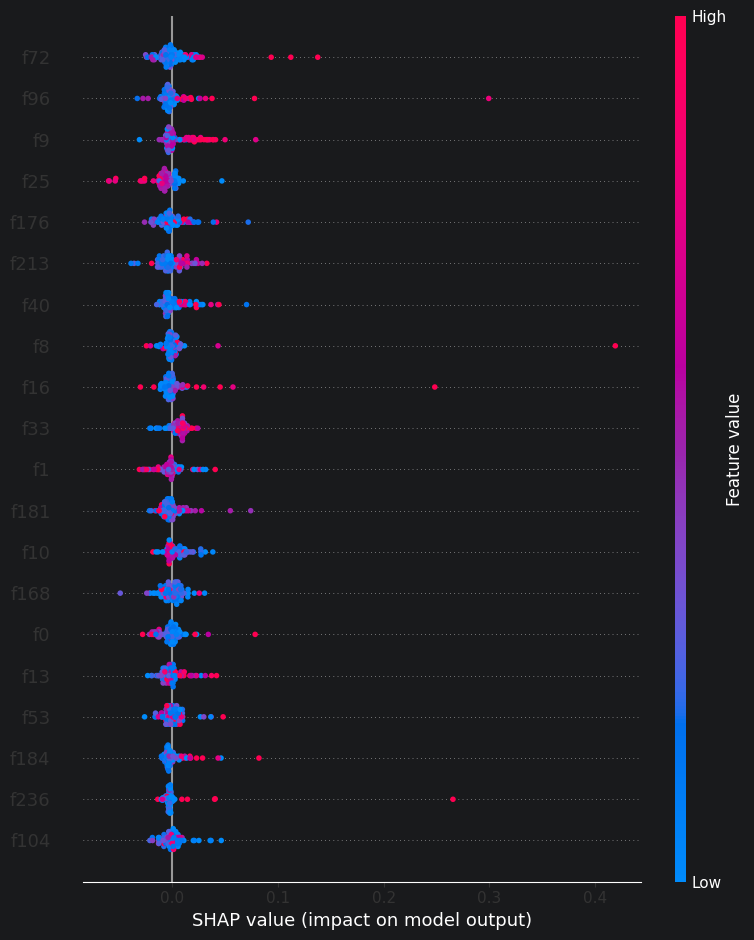

In [74]:
import shap


explainer = shap.Explainer(xgb_mag)
shap_values = explainer(Xtr_flat[:100])  # sample of training data


shap.summary_plot(shap_values, features=Xtr_flat[:100], feature_names=[f"f{i}" for i in range(Xtr_flat.shape[1])])


In [75]:
def predict_with_mc_dropout(model, x, mc_runs=50):
    model.train()
    preds = []


    with torch.no_grad():
        for _ in range(mc_runs):
            mag, _, prob = model(x)


            stacked = torch.stack([mag, prob], dim=1)
            preds.append(stacked.detach().cpu().numpy())

    preds = np.array(preds)
    mean_pred = preds.mean(axis=0)
    std_pred  = preds.std(axis=0)
    return mean_pred, std_pred



In [76]:
import os

print(os.getcwd())

C:\Users\User\AppData\Local\JetBrains\PyCharm 2025.1.3.1\bin


In [77]:
import os

print(os.listdir())

['brokenPlugins.db', 'data', 'defender-exclusions.ps1', 'elevator.exe', 'figures', 'format.bat', 'fsnotifier.exe', 'idea.properties', 'indonesia_earthquake_data.csv', 'inspect.bat', 'jetbrains_client64.exe', 'jetbrains_client64.exe.vmoptions', 'launcher.exe', 'ltedit.bat', 'pipeline.pkl', 'pipeline_student_performance.pkl', 'placement_model.pkl', 'pycharm.bat', 'pycharm.ico', 'pycharm.svg', 'pycharm64.exe', 'pycharm64.exe.vmoptions', 'remote-dev-server.exe', 'restarter.exe', 'ttyfix', 'Uninstall.exe', 'WinProcessListHelper.exe', 'WinShellIntegrationBridge.dll', 'wslhash', 'wslproxy']
